In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chaudharyhimanshu/salary/Salary_dataset.csv


In [68]:
df = pd.read_csv('/kaggle/input/datasets/chaudharyhimanshu/salary/Salary_dataset.csv')


In [69]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [70]:
df = df.iloc[:, 1:]


In [71]:
df.sample(5)

,YearsExperience,Salary
19,6.1,93941.0
15,5.0,67939.0
0,1.2,39344.0
11,4.1,55795.0
6,3.1,60151.0


Text(0, 0.5, 'Salary')

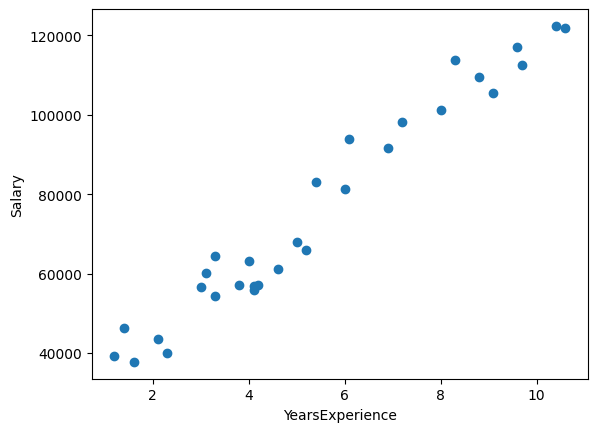

In [72]:
import matplotlib.pyplot as plt
plt.scatter(df['YearsExperience'],df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')

In [73]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [74]:
y

0      39344.0
1      46206.0
2      37732.0
3      43526.0
4      39892.0
5      56643.0
6      60151.0
7      54446.0
8      64446.0
9      57190.0
10     63219.0
11     55795.0
12     56958.0
13     57082.0
14     61112.0
15     67939.0
16     66030.0
17     83089.0
18     81364.0
19     93941.0
20     91739.0
21     98274.0
22    101303.0
23    113813.0
24    109432.0
25    105583.0
26    116970.0
27    112636.0
28    122392.0
29    121873.0
Name: Salary, dtype: float64

In [75]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
lr = LinearRegression()

In [78]:
lr.fit(x_train,y_train)

LinearRegression()

In [79]:
x_test

,YearsExperience
1,1.4
0,1.2
14,4.6
9,3.8
21,7.2
19,6.1


In [80]:
y_test

1     46206.0
0     39344.0
14    61112.0
9     57190.0
21    98274.0
19    93941.0
Name: Salary, dtype: float64

In [81]:
lr.predict(x_test.iloc[2].values.reshape(1,1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([67457.3101364])

In [82]:
m = lr.coef_
m

array([9569.58688543])

In [83]:
b = lr.intercept_
b

np.float64(23437.21046340505)

In [84]:
# y = mx + b
m*4.6+b

array([67457.3101364])

In [85]:
# Regression Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [86]:
y_pred = lr.predict(x_test)

In [87]:
y_test.values

array([46206., 39344., 61112., 57190., 98274., 93941.])

In [88]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 6802.779572073905


In [89]:
print("MSE", mean_squared_error(y_test,y_pred))

MSE 56137509.99782566


In [90]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 7492.49691343451


In [91]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.8886956733784561


In [92]:
# Adjusted R2 score
x_test.shape

(6, 1)

In [93]:
1 - ((1-r2)*(6-1)/(6-1-1))

0.8608695917230702

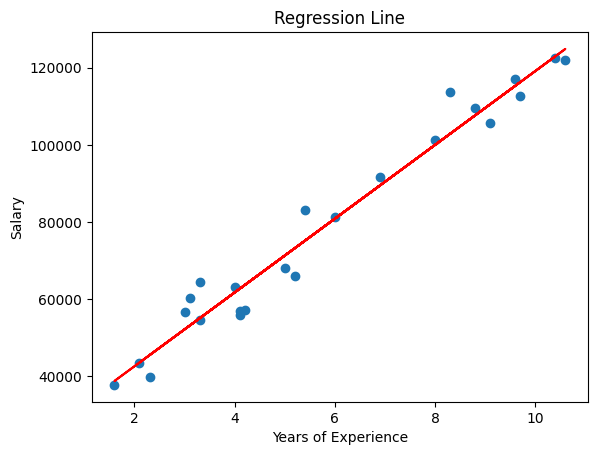

In [94]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train)
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()